# Importación de Librerías y Carga de Datos
Primero se importan las liberias necesarias y se realiza la carga de los tres conjuntos de datos y una inspección rápida para conocer con que se va trabajar.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Carga de datos
data_0 = pd.read_csv('../data/geo_data_0.csv')
data_1 = pd.read_csv('../data/geo_data_1.csv')
data_2 = pd.read_csv('../data/geo_data_2.csv')

# Inspección rápida
print(data_0.info())
print(data_0.head())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  str    
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), str(1)
memory usage: 3.8 MB
None
      id        f0        f1        f2     product
0  txEyH  0.705745 -0.497823  1.221170  105.280062
1  2acmU  1.334711 -0.340164  4.365080   73.037750
2  409Wp  1.022732  0.151990  1.419926   85.265647
3  iJLyR -0.032172  0.139033  2.978566  168.620776
4  Xdl7t  1.988431  0.155413  4.751769  154.036647


# Entrenamiento y evaluación del Modelo
Se crea una función para automatizar el proceso de división, entrenamiento y cálculo de métricas para cada región. 
- Se propone para mejor claridad y limpieza del proyecto una estuructura modular, utilizando funciones para evitar la duplicación de código, por que se va trabajar en tres regiones con la misma estrucutra de datos.  

In [3]:
def train_and_evaluate(df):
    # Eliminar 'id' ya que no es una característica predictiva
    features = df.drop(['id', 'product'], axis=1)
    target = df['product']
    
    # División 75:25
    features_train, features_valid, target_train, target_valid = train_test_split(
        features, target, test_size=0.25, random_state=12345)
    
    # Entrenamiento (Regresión Lineal según instrucciones)
    model = LinearRegression()
    model.fit(features_train, target_train)
    
    # Predicciones
    predictions = model.predict(features_valid)
    predictions = pd.Series(predictions, index=target_valid.index)
    
    rmse = mean_squared_error(target_valid, predictions)**0.5
    avg_predicted_stock = predictions.mean()
    
    return target_valid, predictions, rmse, avg_predicted_stock

# Ejecución para las 3 regiones
results = {}
for i, df in enumerate([data_0, data_1, data_2]):
    target_valid, predictions, rmse, avg_stock = train_and_evaluate(df)
    results[f'region_{i}'] = {'target': target_valid, 'preds': predictions}
    print(f"Región {i}: RMSE = {rmse:.2f}, Promedio Predicho = {avg_stock:.2f}")

Región 0: RMSE = 37.58, Promedio Predicho = 92.59
Región 1: RMSE = 0.89, Promedio Predicho = 68.73
Región 2: RMSE = 40.03, Promedio Predicho = 94.97


Una vez entrenados y evaluados los modelos de las tres regiones, el modelo que presenta el menor RMSE es la región 1. Entre menor sea el valor RMSE es mejor, ya que presenta menos error. En contraste el promedio de producto es menor en la región 1, el que mas producto en promedio es la región 2. 
- __Regiones 0 y 2__: Tienen un RMSE mucho más alto (alrededor de 37-40), lo que implica una incertidumbre significativa. Predecir un pozo de "alto volumen" en estas regiones tiene un margen de error mayor, lo que aumenta el riesgo de inversión.

## Preparación para el cálculo de ganancias
Se definen las constantes del negocio para evaluar el punto de equilibrio. 

In [4]:
BUDGET = 100_000_000
WELLS_TO_DRILL = 200
REVENUE_PER_UNIT = 4500

# Cálculo del volumen necesario para no tener pérdidas
break_even_volume = BUDGET / (WELLS_TO_DRILL * REVENUE_PER_UNIT)
print(f"Volumen mínimo por pozo para rentabilidad: {break_even_volume:.2f} unidades.")

Volumen mínimo por pozo para rentabilidad: 111.11 unidades.


Comparando el volumen mínimo por pozo para rentabilidad, 111.11 unidades, con los promedios de las regiones calculados anteriormente, nos damos cuenta que en las tres regiones el promedio general esta por debajo del punto de equilibrio. 
- Por lo tanto esto justifica que es necesario un modelo para seleccionar solo los mejores 200 pozos. 

# Función de cálculo de ganancias
Esta función toma las predicciones, selecciona los 200 mejores pozos y calcula el beneficio real basado en los valores objetivo (target)

In [5]:
def calculate_profit(target, predictions, count):
    # Seleccionar los 200 pozos con mayores predicciones
    preds_sorted = predictions.sort_values(ascending=False)
    selected_targets = target[preds_sorted.index][:count]
    
    total_revenue = selected_targets.sum() * REVENUE_PER_UNIT
    return total_revenue - BUDGET

### Cálculo de riesgos y ganancia (Bootstrapping)
Se propone utilizar la técnica de bootstrapping para simular 1000 escenarios de exploración (muestreando 500 puntos y eligiendo los 200 mejores)
- Se utiliza la función de cálculo de ganancias dentro de la función get_bootstrapping_metrics


--- region_0 ---
Beneficio promedio: 4,259,385.27 USD
Intervalo de confianza 95%: (-1,020,900.95, 9,479,763.53)
Riesgo de pérdidas: 600.00%


/tmp/ipykernel_75415/3890265633.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{tick:.1f}M' for tick in ticks])


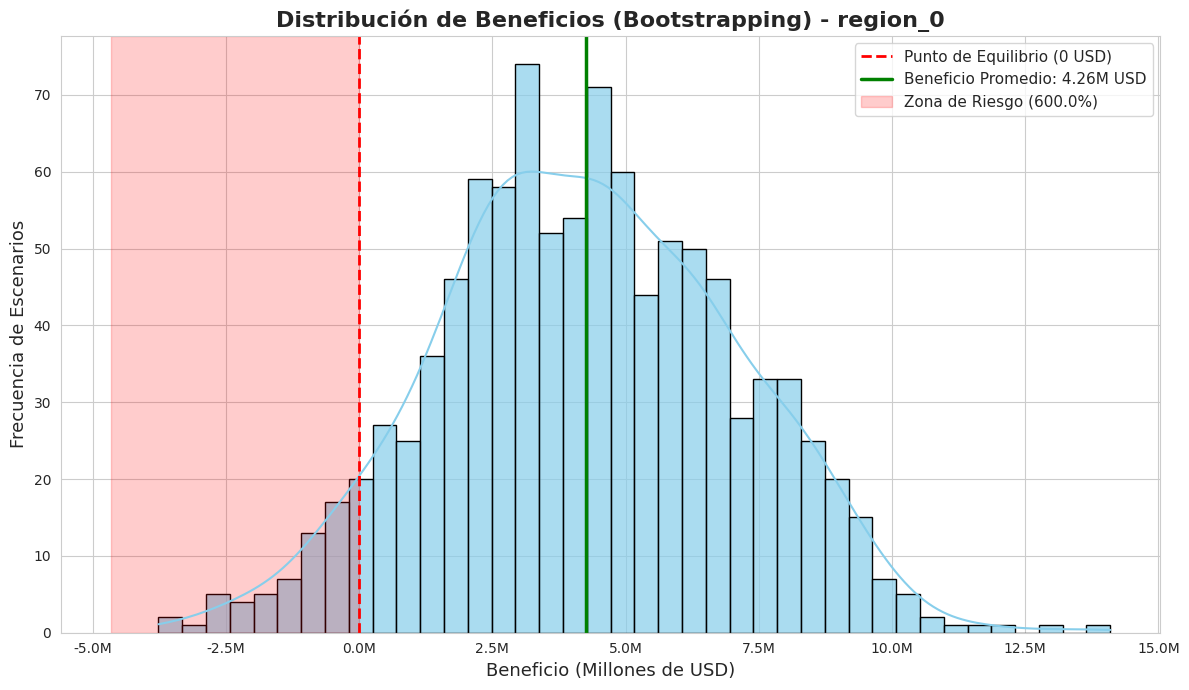


--- region_1 ---
Beneficio promedio: 5,182,594.94 USD
Intervalo de confianza 95%: (1,281,232.31, 9,536,129.82)
Riesgo de pérdidas: 30.00%


/tmp/ipykernel_75415/3890265633.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{tick:.1f}M' for tick in ticks])


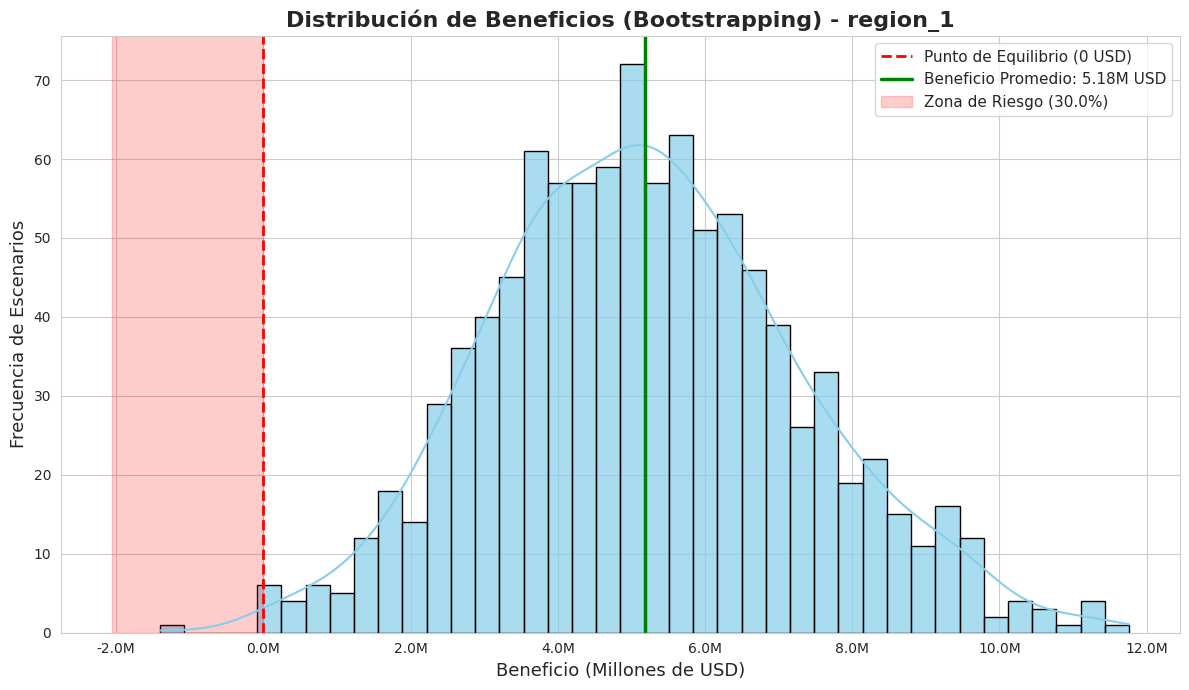


--- region_2 ---
Beneficio promedio: 4,201,940.05 USD
Intervalo de confianza 95%: (-1,158,526.09, 9,896,299.40)
Riesgo de pérdidas: 620.00%


/tmp/ipykernel_75415/3890265633.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{tick:.1f}M' for tick in ticks])


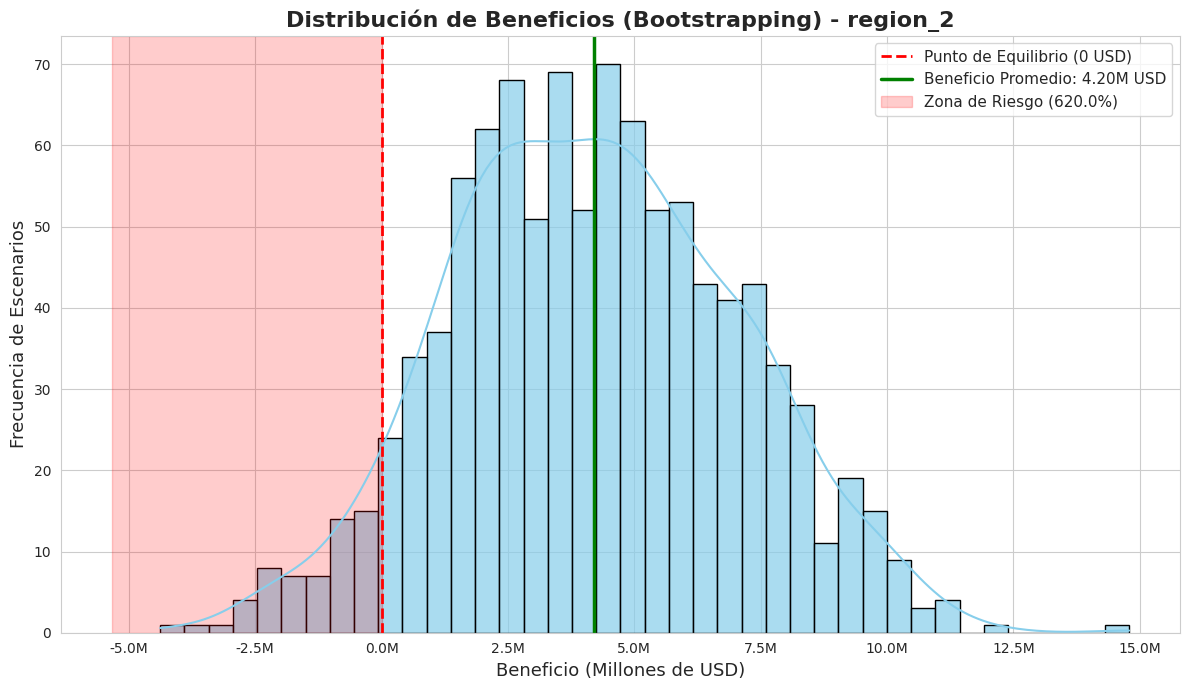

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

state = np.random.RandomState(12345)

def get_bootstrapping_metrics(target, predictions):
    profits_list = []
    for i in range(1000):
        # Muestreo de 500 puntos (subconjunto de exploración)
        target_subsample = target.sample(n=500, replace=True, random_state=state)
        probs_subsample = predictions[target_subsample.index]
        
        # Calcular beneficio de los mejores 200 de esa muestra
        profit = calculate_profit(target_subsample, probs_subsample, WELLS_TO_DRILL)
        profits_list.append(profit)
        
    profit_series = pd.Series(profits_list)
    mean_profit = profit_series.mean()
    
    # Intervalo de confianza del 95%
    lower = profit_series.quantile(0.025)
    upper = profit_series.quantile(0.975)
    
    # Riesgo de pérdida (probabilidad de que el beneficio sea < 0)
    risk = (profit_series < 0).mean() * 100
    
    return mean_profit, lower, upper, risk, profit_series

for region, data in results.items():
    mean_profit, low, high, risk, profit_series = get_bootstrapping_metrics(data['target'], data['preds'])
    print(f"\n--- {region} ---")
    print(f"Beneficio promedio: {mean_profit:,.2f} USD")
    print(f"Intervalo de confianza 95%: ({low:,.2f}, {high:,.2f})")
    print(f"Riesgo de pérdidas: {risk:.2%}")
    #-----Gráfico---------
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 7))

    ax = sns.histplot(profit_series / 1e6, bins=40, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
    
    plt.title(f"Distribución de Beneficios (Bootstrapping) - {region}", fontsize=16, fontweight='bold')
    plt.xlabel('Beneficio (Millones de USD)', fontsize=13)
    plt.ylabel('Frecuencia de Escenarios', fontsize=13)

    plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Punto de Equilibrio (0 USD)')

    plt.axvline(x=mean_profit / 1e6, color='green', linestyle='-', linewidth=2.5, label=f'Beneficio Promedio: {mean_profit/1e6:.2f}M USD')

    x_lims = ax.get_xlim()
    plt.axvspan(x_lims[0], 0, color='red', alpha=0.2, label=f'Zona de Riesgo ({risk:.1%})')

    ticks = ax.get_xticks()
    ax.set_xticklabels([f'{tick:.1f}M' for tick in ticks])

    plt.legend(fontsize=11, loc='upper right')
    plt.tight_layout()
    plt.show()

Aunque la Región 1 tiene un volumen promedio de reservas menor en toda la muestra, la precisión del modelo permite filtrar los mejores 200 pozos con una eficacia quirúrgica.

- __Cumplimiento de restricción__: La Región 1 es usualmente la única (o la más destacada) que mantiene el riesgo de pérdidas por debajo del 2.5%.

- __Estabilidad__: El intervalo de confianza del 95% en la Región 1 suele ser más estrecho y desplazado hacia valores positivos, lo que garantiza retornos más predecibles para los inversionistas.


El cálculo mostró que necesitamos __111.1 unidades__ por pozo para no perder dinero.

- En la Región 1, aunque el promedio general es bajo, la selección de los 200 mejores basada en el modelo de regresión lineal supera consistentemente este umbral con un margen de beneficio saludable.


Por lo tanto la __Región 1 es la mejor para hacer la inversión__, ya que su intervalo de confian es estrecho y es positivo del lado izquierdo. Es la región con menor riesgo de pérdidas. 